In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

import os
# os.environ["OMP_NUM_THREADS"] = "9"


In [65]:
#read in the exoplanet data
df = pd.read_csv('exoplanets.csv', comment='#', low_memory=False)
# We sort by planet name
df_sorted = df.sort_values(by=['pl_name', 'default_flag'], ascending=[True, False])

# .first() will take the first non-null value it encounters for each column in the group
df_combined = df_sorted.groupby('pl_name', as_index=False).first()

features = df_combined[['pl_rade', 'pl_masse', 'pl_dens', 'pl_orbper']].copy()
e_massg = 5.97e27
e_radcm  = 6.37e8

features['pl_dens'] = features['pl_masse']/(4.0/3.0*np.pi*features['pl_rade']**3) * (e_massg/e_radcm**3)

#drop NaNs
sample = features.dropna()
sample_arr = sample.values

# norm_koeffs =
# norm_data = sample_arr/np.mean(sample_arr, axis = 0)
log_data = np.log10(sample_arr)
norm_koeffs =np.mean(log_data, axis = 0)
log_data = log_data/norm_koeffs
log_data_MR = log_data[:,:2]
log_data_RD = log_data[:,1:3]

print(log_data.shape)

(1684, 4)


In [66]:
ss_planets = pd.read_csv('Solar_system.csv', usecols=[2,3,4, 6], skiprows=2,
                         names=['radius', 'mass', 'bulk density', 'orbital period'])
# ss_planets['solar mass'] = 1
ss_planets['mass'] = ss_planets.apply(lambda x: float(x['mass'].split()[0]), axis=1)
ss_planets['radius'] = ss_planets.apply(lambda x: float(x['radius'].split()[0]), axis=1)
ss_planets['orbital period'] = ss_planets.apply(lambda x: float(x['orbital period'].split()[0]), axis=1)
ss_planets['bulk density'] = ss_planets.apply(lambda x: float(x['bulk density'].split()[0]), axis=1)

ss_planets['mass'] = ss_planets['mass']/ss_planets.loc[2]['mass']
ss_planets['radius'] = ss_planets['radius']/ss_planets.loc[2]['radius']
ss_planets['orbital period'] = ss_planets['orbital period']*365.2425
ss_planets['bulk density'] = ss_planets['bulk density']

planet_names  = ['Mercury','Venus','Earth','Mars','Jupiter','Saturn','Uranus','Neptune']
ss_feat = ss_planets.values

ss_log = np.log10(ss_feat)/norm_koeffs
ss_colors = ['orange', 'gold', 'green', 'red', 'sienna', 'goldenrod', 'mediumturquoise', 'deepskyblue']


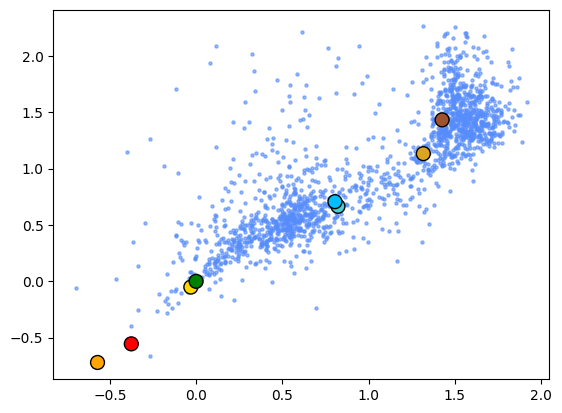

In [67]:
plt.scatter(log_data[:,0], log_data[:,1], s=5, alpha=0.6)
plt.scatter(ss_log[:,0], ss_log[:,1], color=ss_colors, s=100, edgecolors='black')

## BIC calculation

In [24]:
def bic(X):
    bic_scores=[]
    models = dict()
    for k in range(1,10):
        gm=GaussianMixture(n_components=k).fit(X)
        bic_scores.append(gm.bic(X))
        models[k] = gm
    return bic_scores

In [25]:
b1=bic(log_data)
b2=bic(log_data_MR)
b3=bic(log_data_RD)
bics = [b1,b2,b3]


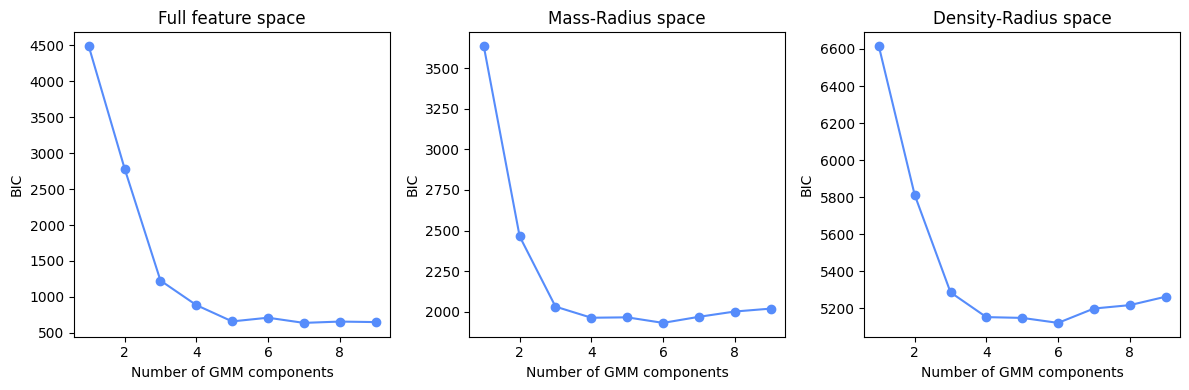

In [26]:
labels = ['Full feature space', 'Mass-Radius space', 'Density-Radius space']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, ax in enumerate(axes):
    ax.plot(range(1,10), bics[i], marker='o')
    ax.set_title(labels[i])
    ax.set_xlabel('Number of GMM components')
    ax.set_ylabel('BIC')

plt.tight_layout()
plt.savefig('bic_comparison.png')
plt.show()

In [27]:
def delta_bic(bic):
    delta_bic = []
    for k in range(1,9):
        delta_bic.append(bic[k-1]-bic[k])
    return delta_bic


In [28]:
delta_bics = [delta_bic(b1), delta_bic(b2), delta_bic(b3)]

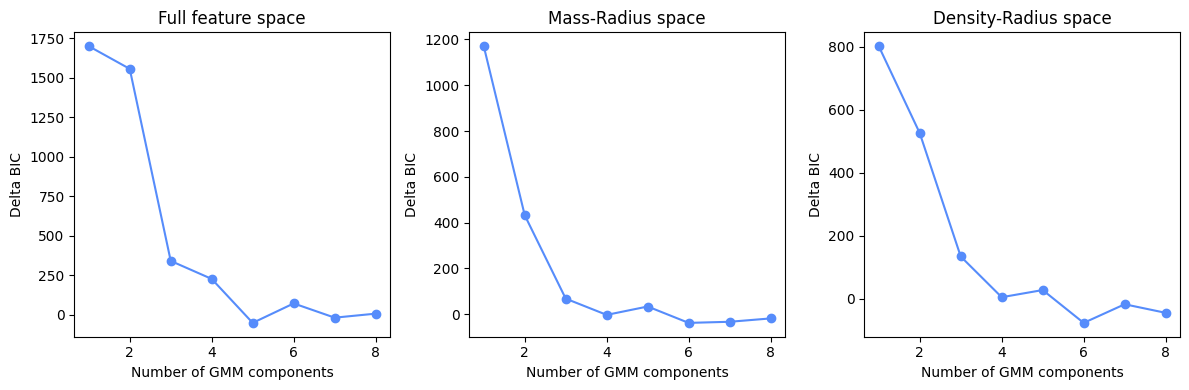

In [29]:
labels = ['Full feature space', 'Mass-Radius space', 'Density-Radius space']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, ax in enumerate(axes):
    ax.plot(range(1,9), delta_bics[i], marker='o')
    ax.set_title(labels[i])
    ax.set_xlabel('Number of GMM components')
    ax.set_ylabel('Delta BIC')

plt.tight_layout()
plt.savefig('delta_bic_comparison.png')
plt.show()


In [83]:
X_train, X_test = train_test_split(log_data, test_size=0.01, random_state=42)
gmm_best = GaussianMixture(n_components=6, random_state=42)
gmm_best.fit(X_train)
y_train = gmm_best.predict(X_train)
y_test = gmm_best.predict(X_test)




In [84]:
gmm_best.predict(ss_log)

array([3, 3, 3, 3, 4, 4, 2, 2])

## Plotting results

In [ ]:
##

In [78]:

y_train_all = gmm_best.predict(log_data)
i_x = 0
i_y = 1
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(log_data[:, i_x]*norm_koeffs[i_x], log_data[:, i_y]*norm_koeffs[i_y],
                     c=y_train_all, cmap='tab10', s=5, alpha=0.4)
scatter_ss = ax.scatter(ss_log[:, i_x]*norm_koeffs[i_x], ss_log[:, i_y]*norm_koeffs[i_y], marker='p', color=ss_colors, s=100, edgecolors='black')

ax.set_xlabel(r'$\log_{10}(R) [ R_\oplus])$')
ax.set_ylabel(r'$\log_{10}(M) [ M_\oplus])$')
ax.set_title('GMM clusters in All feature space')
plt.colorbar(scatter, ax=ax, label='label')
plt.tight_layout()
plt.show()

array([3, 3, 3, 3, 4, 4, 2, 2])

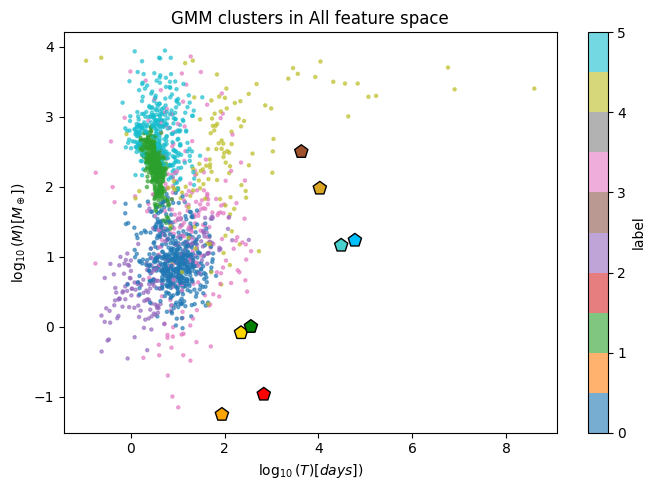

In [74]:

y_train_all = gmm_best.predict(log_data)
i_x = 3
i_y = 1

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(log_data[:, i_x]*norm_koeffs[i_x], log_data[:, i_y]*norm_koeffs[i_y],
                     c=y_train_all, cmap='tab10', s=5, alpha=0.6)
scatter_ss = ax.scatter(ss_log[:, i_x]*norm_koeffs[i_x], ss_log[:, i_y]*norm_koeffs[i_y], marker='p', color=ss_colors, s=100, edgecolors='black')

ax.set_xlabel(r'$\log_{10}(T) [days])$')
ax.set_ylabel(r'$\log_{10}(M) [ M_\oplus])$')
ax.set_title('GMM clusters in All feature space')
plt.colorbar(scatter, ax=ax, label='label')
plt.tight_layout()
plt.show()

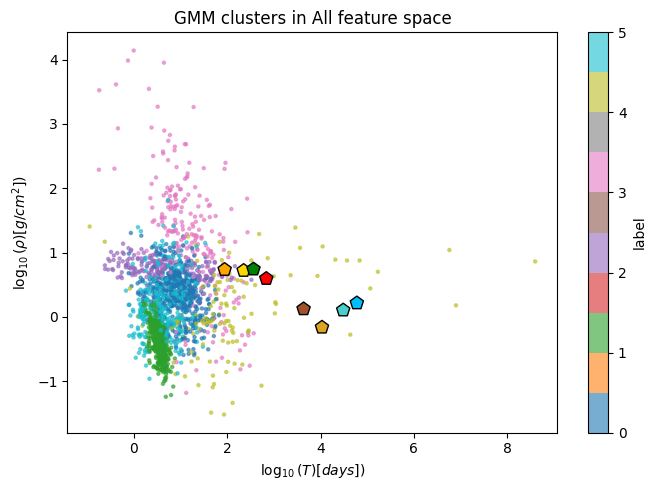

In [76]:

y_train_all = gmm_best.predict(log_data)
i_x = 3
i_y = 2

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(log_data[:, i_x]*norm_koeffs[i_x], log_data[:, i_y]*norm_koeffs[i_y],
                     c=y_train_all, cmap='tab10', s=5, alpha=0.6)
scatter_ss = ax.scatter(ss_log[:, i_x]*norm_koeffs[i_x], ss_log[:, i_y]*norm_koeffs[i_y], marker='p', color=ss_colors, s=100, edgecolors='black')

ax.set_xlabel(r'$\log_{10}(T) [days])$')
ax.set_ylabel(r'$\log_{10}(\rho) [g/cm^2])$')
ax.set_title('GMM clusters in All feature space')
plt.colorbar(scatter, ax=ax, label='label')
plt.tight_layout()
plt.show()

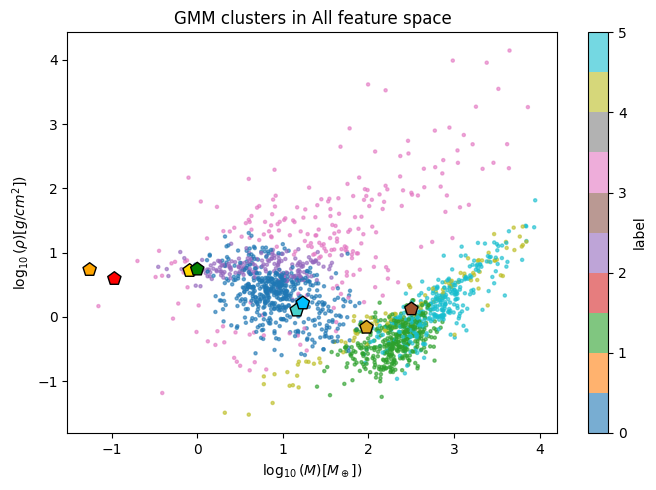

In [77]:

y_train_all = gmm_best.predict(log_data)

i_x = 1
i_y = 2

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(log_data[:, i_x]*norm_koeffs[i_x], log_data[:, i_y]*norm_koeffs[i_y],
                     c=y_train_all, cmap='tab10', s=5, alpha=0.6)
scatter_ss = ax.scatter(ss_log[:, i_x]*norm_koeffs[i_x], ss_log[:, i_y]*norm_koeffs[i_y], marker='p', color=ss_colors, s=100, edgecolors='black')

ax.set_xlabel(r'$\log_{10}(M) [ M_\oplus])$')
ax.set_ylabel(r'$\log_{10}(\rho) [g/cm^2])$')
ax.set_title('GMM clusters in All feature space')
plt.colorbar(scatter, ax=ax, label='label')
plt.tight_layout()
plt.show()

In [79]:
## KNN

In [82]:

knn = KNeighborsClassifier(n_neighbors=30, weights = 'distance' , p = 2)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)


In [81]:
# X_ss = ss_log.T

knn.predict(ss_log)

array([0, 2, 2, 2, 4, 4, 4, 4])

In [202]:
#do accuracy test here
score = knn.score(X_test, y_test)

print(score)

0.90625


In [203]:
svm = SVC()
svm.fit(X_train, y_train)

#svm.predict(X_test)

svm.predict(X_ss)

array([2, 2, 2, 1, 2, 2, 1, 1])

In [204]:
gmm_best.predict_proba(X_ss)

array([[6.40683719e-210, 9.52968938e-005, 9.99904655e-001,
        4.77382849e-008, 6.85986438e-031],
       [7.04334313e-215, 1.07020699e-009, 9.99999999e-001,
        2.28296397e-016, 8.27024443e-035],
       [2.70922593e-210, 4.54331995e-008, 9.99999955e-001,
        1.35938068e-015, 8.77111598e-032],
       [1.27044159e-181, 9.99999462e-001, 1.40442168e-010,
        5.38228981e-007, 2.11967837e-027],
       [3.66130080e-049, 9.01463524e-003, 9.90984331e-001,
        5.07058914e-007, 5.26963730e-007],
       [1.38015614e-058, 9.45535682e-001, 5.44604556e-002,
        1.23806786e-008, 3.84978359e-006],
       [2.29199345e-074, 9.99999995e-001, 3.87695760e-019,
        5.20582080e-009, 6.84405808e-021],
       [1.35859260e-067, 9.99999977e-001, 8.37777198e-027,
        2.34903859e-008, 1.37143470e-028]])